# 02 - Variational Quantum Classifiers

A variational quantum classifier (VQC) combines a data encoding circuit with trainable gates:

$$
|\psi(x,\theta)\rangle = U_\theta U_\phi(x)|0\cdots 0\rangle.
$$

The model prediction is obtained from measurements. For binary classification one common choice is

$$
\hat y(x,\theta) = \langle Z_0 \rangle_{\psi(x,\theta)}.
$$

With labels $$y \in \{-1,+1\}$$, a simple loss is mean squared error:

$$
J(\theta,b) = \frac{1}{n}\sum_{i=1}^n \left(\langle Z_0 \rangle_{\psi(x_i,\theta)} + b - y_i\right)^2.
$$

This notebook covers measurements, losses, gradients, a small Iris classifier, a hybrid PyTorch/PennyLane model, and a practical warning: barren plateaus.


## Measurements and gradients

A quantum circuit returns samples or expectation values. For the one-qubit state

$$
R_Y(\theta)|0\rangle
=
\cos(\theta/2)|0\rangle+\sin(\theta/2)|1\rangle,
$$

the expectation of \(Z\) is

$$
\langle Z\rangle = P(0)-P(1)=\cos(\theta).
$$

Many rotation-gate gradients can be measured with the parameter-shift rule:

$$
\frac{\partial f(\theta)}{\partial \theta}
=
\frac{1}{2}
\left[
f\left(\theta+\frac{\pi}{2}\right)
-
f\left(\theta-\frac{\pi}{2}\right)
\right].
$$

This is important because it estimates exact circuit derivatives using circuit evaluations, without differentiating through a matrix simulation.


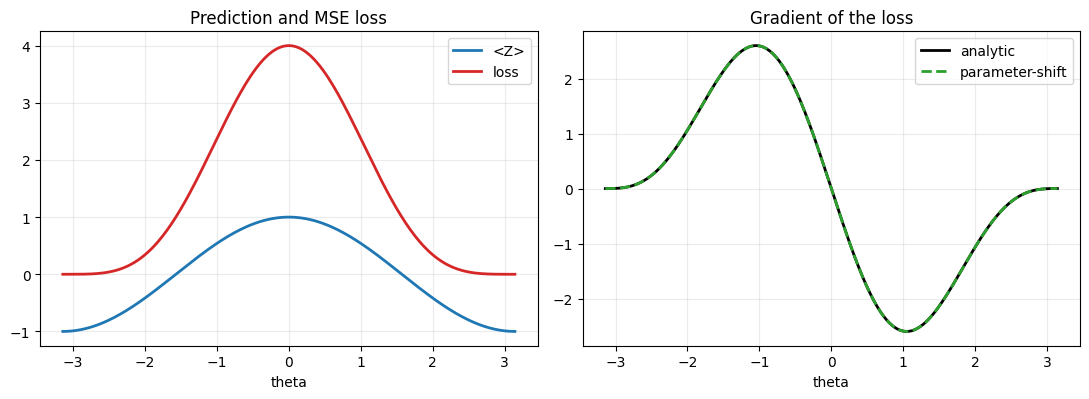

max gradient difference: 8.881784197001252e-16


In [1]:
# Pseudo-code:
#   1. define a one-qubit measurement model
#   2. compute loss across parameter values
#   3. estimate gradients by parameter shift
#   4. compare analytic and shifted gradients

# Measurement, loss, and parameter-shift gradient for a one-qubit model.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

target = -1.0
theta_values = np.linspace(-np.pi, np.pi, 300)

dev = qml.device("default.qubit", wires=1)
# Create the quantum simulator backend.

@qml.qnode(dev)
def model(theta):
    # Define the reusable computation for this cell.
    qml.RY(theta, wires=0)
    # Apply a quantum operation or declare a measurement.
    return qml.expval(qml.PauliZ(0))
    # Return the computed output for the caller.

predictions = np.array([model(theta) for theta in theta_values])
# Compute model outputs for the current data.
losses = (predictions - target) ** 2
# Compute the training objective being minimized.
analytic_gradient = -2.0 * (np.cos(theta_values) - target) * np.sin(theta_values)
# Compute a gradient signal for parameter updates.
shifted_gradient = []

for theta in theta_values:
    # Iterate through this part of the algorithm.
    f_plus = model(theta + np.pi / 2.0)
    f_minus = model(theta - np.pi / 2.0)
    d_prediction = 0.5 * (f_plus - f_minus)
    # Compute model outputs for the current data.
    shifted_gradient.append(2.0 * (model(theta) - target) * d_prediction)
    # Save this value so the learning trajectory can be plotted.
shifted_gradient = np.array(shifted_gradient)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.1))

axes[0].plot(theta_values, predictions, color="tab:blue", linewidth=2, label="<Z>")
axes[0].plot(theta_values, losses, color="tab:red", linewidth=2, label="loss")
axes[0].set_title("Prediction and MSE loss")
axes[0].set_xlabel("theta")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(theta_values, analytic_gradient, color="black", linewidth=2, label="analytic")
axes[1].plot(theta_values, shifted_gradient, color="tab:green", linestyle="--", linewidth=2, label="parameter-shift")
axes[1].set_title("Gradient of the loss")
axes[1].set_xlabel("theta")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print("max gradient difference:", np.max(np.abs(analytic_gradient - shifted_gradient)))


## Iris dataset setup

The Iris dataset has four measurements per flower:

$$
x = [\text{sepal length}, \text{sepal width}, \text{petal length}, \text{petal width}].
$$

To keep the circuit small, the example below uses two classes and two features:

- Iris setosa versus Iris versicolor,
- petal length and petal width,
- labels \(y=-1\) and \(y=+1\).

The features are standardized and then scaled into rotation angles. The model is intentionally tiny: two qubits, angle encoding, a few trainable rotations, and one \(Z\)-expectation measurement.


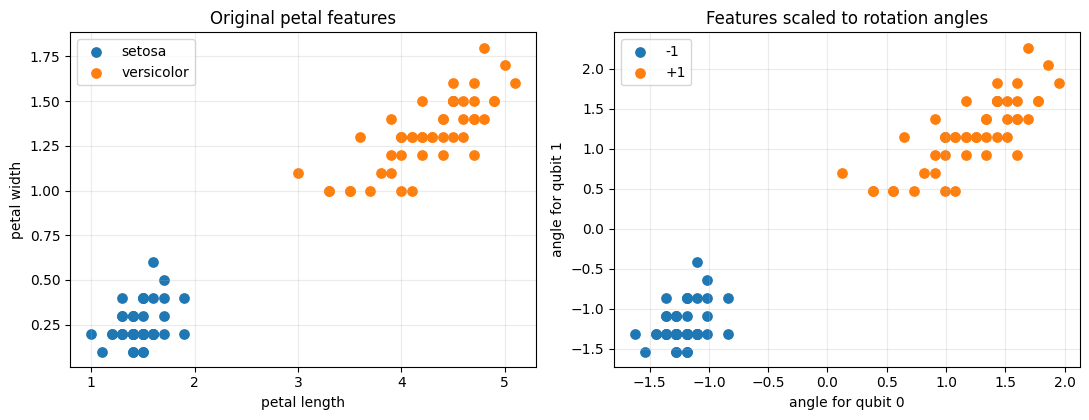

data shape: (100, 2)
angle range: -1.621 to 2.266


In [2]:
# Pseudo-code:
#   1. load binary Iris data
#   2. select two petal features
#   3. scale features into rotation angles
#   4. plot original and encoded features

# Inspect the binary Iris task used by the VQC.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
# Load the standard Iris dataset.
X_all = iris.data
y_all = iris.target
names = iris.target_names

mask = y_all < 2
X = X_all[mask][:, [2, 3]]
y = np.where(y_all[mask] == 0, -1.0, 1.0)

feature_mean = X.mean(axis=0)
feature_scale = X.std(axis=0)
X_standard = (X - feature_mean) / feature_scale
X_angles = np.clip(X_standard, -2.5, 2.5) * (np.pi / 2.5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].scatter(X[y == -1, 0], X[y == -1, 1], s=45, color="tab:blue", label=names[0])
axes[0].scatter(X[y == 1, 0], X[y == 1, 1], s=45, color="tab:orange", label=names[1])
axes[0].set_title("Original petal features")
axes[0].set_xlabel("petal length")
axes[0].set_ylabel("petal width")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].scatter(X_angles[y == -1, 0], X_angles[y == -1, 1], s=45, color="tab:blue", label="-1")
axes[1].scatter(X_angles[y == 1, 0], X_angles[y == 1, 1], s=45, color="tab:orange", label="+1")
axes[1].set_title("Features scaled to rotation angles")
axes[1].set_xlabel("angle for qubit 0")
axes[1].set_ylabel("angle for qubit 1")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print("data shape:", X.shape)
print("angle range:", round(float(X_angles.min()), 3), "to", round(float(X_angles.max()), 3))


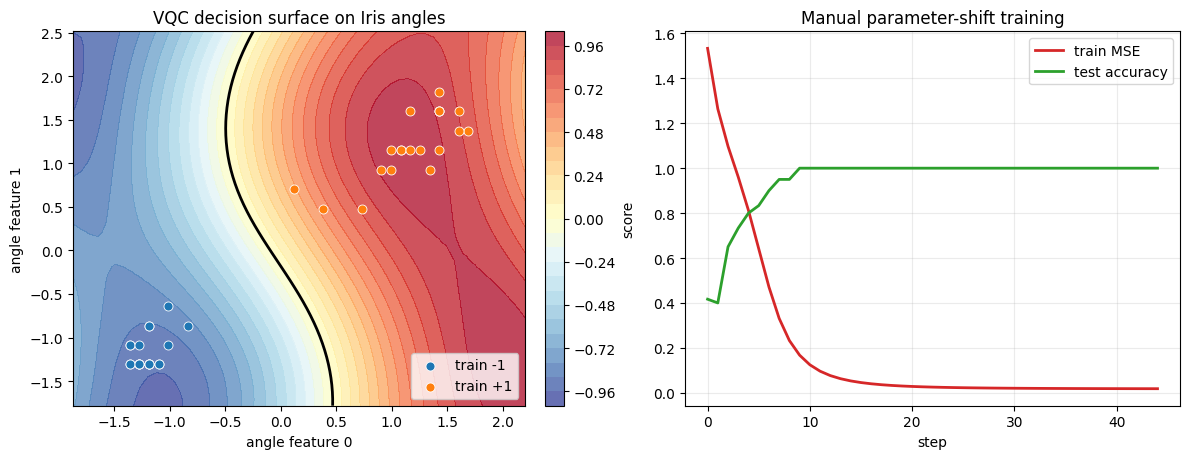

train accuracy=1.000
test accuracy=1.000
weights: [-1.095 -1.421  0.245  0.567] bias: 0.014


In [ ]:
# Pseudo-code:
#   1. prepare a binary Iris train/test split
#   2. define a two-qubit VQC
#   3. train with manual parameter-shift gradients
#   4. plot the learned decision surface

# VQC on binary Iris using a manual parameter-shift training loop.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.datasets import load_iris

rng = np.random.default_rng(23)
iris = load_iris()
# Load the standard Iris dataset.
mask = iris.target < 2
X_raw = iris.data[mask][:, [2, 3]]
y_all = np.where(iris.target[mask] == 0, -1.0, 1.0)

order = rng.permutation(len(X_raw))
X_raw = X_raw[order]
y_all = y_all[order]
feature_mean = X_raw.mean(axis=0)
feature_scale = X_raw.std(axis=0)
X_angles = np.clip((X_raw - feature_mean) / feature_scale, -2.5, 2.5) * (np.pi / 2.5)

n_train = 40
X_train = X_angles[:n_train]
y_train = y_all[:n_train]
X_test = X_angles[n_train:]
y_test = y_all[n_train:]

dev = qml.device("default.qubit", wires=2)
# Create the quantum simulator backend.

@qml.qnode(dev)
def circuit(features, weights):
    # Define the reusable computation for this cell.
    qml.RY(features[0], wires=0)
     
    qml.RY(features[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[0, 1])
    # Apply a quantum operation or declare a measurement.
    qml.RY(weights[0], wires=0)
    # Apply a quantum operation or declare a measurement.
    qml.RY(weights[1], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.RZ(weights[2], wires=0)
    # Apply a quantum operation or declare a measurement.
    qml.RZ(weights[3], wires=1)
    # Apply a quantum operation or declare a measurement.
    qml.CNOT(wires=[1, 0])
    # Apply a quantum operation or declare a measurement.
    return qml.expval(qml.PauliZ(0))
    # Return the computed output for the caller.

weights = rng.normal(0.0, 0.25, size=4)
# Initialize or update trainable model parameters.
bias = 0.0
learning_rate = 0.18
loss_history = []
test_accuracy_history = []

for step in range(45):
    # Iterate through this part of the algorithm.
    predictions = np.array([circuit(x, weights) + bias for x in X_train])
    # Compute model outputs for the current data.
    errors = predictions - y_train
    loss = np.mean(errors**2)
    # Compute the training objective being minimized.
    loss_history.append(loss)
    # Save this value so the learning trajectory can be plotted.

    grad_weights = np.zeros_like(weights)
    # Compute a gradient signal for parameter updates.
    for parameter_index in range(len(weights)):
        # Iterate through this part of the algorithm.
        shifted_plus = weights.copy()
        shifted_minus = weights.copy()
        shifted_plus[parameter_index] += np.pi / 2.0
        shifted_minus[parameter_index] -= np.pi / 2.0
        derivative_predictions = []
        # Compute a gradient signal for parameter updates.
        for x in X_train:
            # Iterate through this part of the algorithm.
            f_plus = circuit(x, shifted_plus)
            f_minus = circuit(x, shifted_minus)
            derivative_predictions.append(0.5 * (f_plus - f_minus))
            # Save this value so the learning trajectory can be plotted.
        derivative_predictions = np.array(derivative_predictions)
        # Compute a gradient signal for parameter updates.
        grad_weights[parameter_index] = np.mean(2.0 * errors * derivative_predictions)
        # Compute a gradient signal for parameter updates.

    grad_bias = np.mean(2.0 * errors)
    # Compute a gradient signal for parameter updates.
    weights = weights - learning_rate * grad_weights
    # Initialize or update trainable model parameters.
    bias = bias - learning_rate * grad_bias

    test_predictions = np.array([circuit(x, weights) + bias for x in X_test])
    # Compute model outputs for the current data.
    test_labels = np.where(test_predictions >= 0.0, 1.0, -1.0)
    test_accuracy_history.append(np.mean(test_labels == y_test))
    # Measure classification performance.

train_predictions = np.array([circuit(x, weights) + bias for x in X_train])
# Compute model outputs for the current data.
train_accuracy = np.mean(np.where(train_predictions >= 0.0, 1.0, -1.0) == y_train)
# Measure classification performance.
test_predictions = np.array([circuit(x, weights) + bias for x in X_test])
# Compute model outputs for the current data.
test_accuracy = np.mean(np.where(test_predictions >= 0.0, 1.0, -1.0) == y_test)
# Measure classification performance.

x0_min, x0_max = X_angles[:, 0].min() - 0.25, X_angles[:, 0].max() + 0.25
x1_min, x1_max = X_angles[:, 1].min() - 0.25, X_angles[:, 1].max() + 0.25
xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 55), np.linspace(x1_min, x1_max, 55))
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_scores = np.array([circuit(x, weights) + bias for x in grid]).reshape(xx.shape)
# Compute model outputs for the current data.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

background = axes[0].contourf(xx, yy, grid_scores, levels=24, cmap="RdYlBu_r", alpha=0.75)
axes[0].contour(xx, yy, grid_scores, levels=[0.0], colors="black", linewidths=2)
axes[0].scatter(X_train[y_train == -1, 0], X_train[y_train == -1, 1], s=42, color="tab:blue", edgecolor="white", linewidth=0.6, label="train -1")
axes[0].scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], s=42, color="tab:orange", edgecolor="white", linewidth=0.6, label="train +1")
axes[0].set_title("VQC decision surface on Iris angles")
axes[0].set_xlabel("angle feature 0")
axes[0].set_ylabel("angle feature 1")
axes[0].legend(loc="lower right")
fig.colorbar(background, ax=axes[0], fraction=0.046, pad=0.04, label="score")

axes[1].plot(loss_history, color="tab:red", linewidth=2, label="train MSE")
axes[1].plot(test_accuracy_history, color="tab:green", linewidth=2, label="test accuracy")
axes[1].set_title("Manual parameter-shift training")
axes[1].set_xlabel("step")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"train accuracy={train_accuracy:.3f}")
print(f"test accuracy={test_accuracy:.3f}")
print("weights:", np.round(weights, 3), "bias:", round(float(bias), 3))


## Hybrid PyTorch plus PennyLane

A hybrid model uses classical neural-network layers and a quantum layer in one differentiable computation graph.

A typical structure is

$$
x
\xrightarrow{\text{classical layer}}
a(x)
\xrightarrow{\text{quantum circuit}}
q(a,\theta)
\xrightarrow{\text{classical layer}}
\hat y.
$$

The next example uses a synthetic XOR-style dataset. A small classical layer maps two coordinates to two quantum angles. The quantum layer returns two expectation values. A final classical layer produces a logit for binary classification.


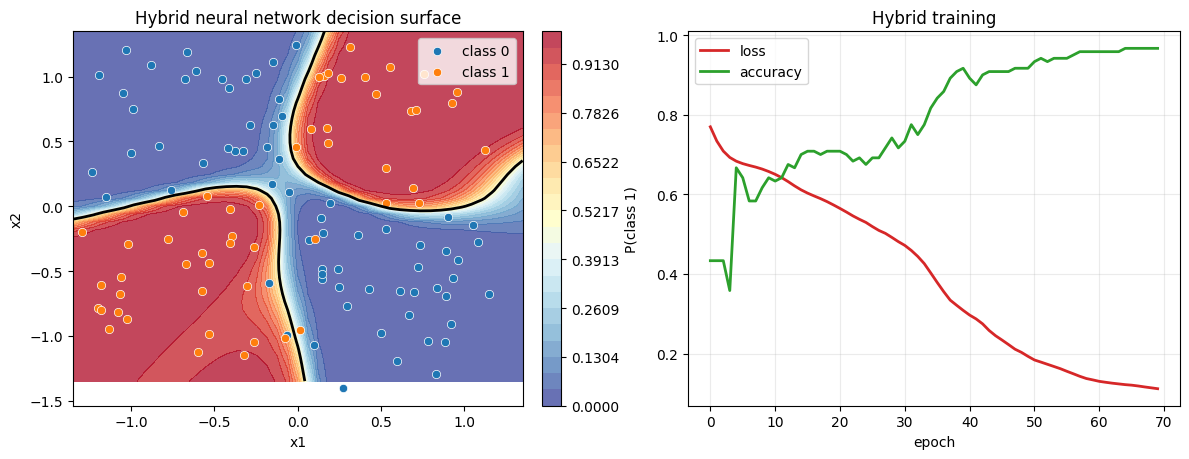

final loss=0.112
final training accuracy=0.967
learned quantum weights: [-1.566  0.249  0.011 -0.243]


In [ ]:
# Pseudo-code:
#   1. generate a nonlinear XOR-style dataset
#   2. define a PyTorch model with a PennyLane layer
#   3. train by backpropagation
#   4. plot the hybrid decision surface

# Hybrid PyTorch/PennyLane classifier on a nonlinear XOR-style dataset.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import torch
import pennylane as qml

torch.manual_seed(5)
rng = np.random.default_rng(5)

n = 120
X_np = rng.uniform(-1.2, 1.2, size=(n, 2)).astype("float32")
y_np = ((X_np[:, 0] * X_np[:, 1]) > 0.0).astype("float32")
X_np = X_np + rng.normal(0.0, 0.08, size=X_np.shape).astype("float32")

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np[:, None], dtype=torch.float32)

dev = qml.device("default.qubit", wires=2)
# Create the quantum simulator backend.

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_layer(angles, q_weights):
    # Define the reusable computation for this cell.
    qml.RY(angles[0], wires=0)
    qml.RY(angles[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(q_weights[0], wires=0)
    qml.RY(q_weights[1], wires=1)
    qml.RZ(q_weights[2], wires=0)
    qml.RZ(q_weights[3], wires=1)
    qml.CNOT(wires=[1, 0])
    
    return qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1))
    # Return the computed output for the caller.

class HybridModel(torch.nn.Module):
    # Define the model structure used in training.
    def __init__(self):
        # Define the reusable computation for this cell.
        super().__init__()
        self.pre = torch.nn.Sequential(
            torch.nn.Linear(2, 6),
            torch.nn.Tanh(),
            torch.nn.Linear(6, 2),
            torch.nn.Tanh(),
        )
        # Create a PyTorch training component.
        self.q_weights = torch.nn.Parameter(0.2 * torch.randn(4))
        # Create a PyTorch training component.
        self.post = torch.nn.Sequential(
            torch.nn.Linear(2, 4),
            torch.nn.Tanh(),
            torch.nn.Linear(4, 1),
        )
        # Create a PyTorch training component.

    def forward(self, x):
        # Define the reusable computation for this cell.
        angles = np.pi * self.pre(x)
        q_outputs = []
        for sample_angles in angles:
            # Iterate through this part of the algorithm.
            z0, z1 = quantum_layer(sample_angles, self.q_weights)
            q_outputs.append(torch.stack([z0, z1]))
            # Save this value so the learning trajectory can be plotted.
        q_outputs = torch.stack(q_outputs).to(dtype=x.dtype)
        return self.post(q_outputs)
        # Return the computed output for the caller.

model = HybridModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.035)
# Create a PyTorch training component.
loss_fn = torch.nn.BCEWithLogitsLoss()
# Create a PyTorch training component.

loss_history = []
accuracy_history = []
for epoch in range(70):
    # Iterate through this part of the algorithm.
    optimizer.zero_grad()
    # Run one optimizer operation in the training loop.
    logits = model(X)
    # Compute model outputs for the current data.
    loss = loss_fn(logits, y)
    # Compute the training objective being minimized.
    loss.backward()
    # Run one optimizer operation in the training loop.
    optimizer.step()
    # Run one optimizer operation in the training loop.

    with torch.no_grad():
        # Enter a scoped block for evaluation without extra side effects.
        predictions = (torch.sigmoid(logits) >= 0.5).float()
        # Compute model outputs for the current data.
        accuracy = (predictions == y).float().mean().item()
        # Measure classification performance.
    loss_history.append(loss.item())
    # Save this value so the learning trajectory can be plotted.
    accuracy_history.append(accuracy)
    # Save this value so the learning trajectory can be plotted.

grid_x = np.linspace(-1.35, 1.35, 45)
grid_y = np.linspace(-1.35, 1.35, 45)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_np = np.column_stack([xx.ravel(), yy.ravel()]).astype("float32")
with torch.no_grad():
    # Enter a scoped block for evaluation without extra side effects.
    grid_logits = model(torch.tensor(grid_np, dtype=torch.float32))
    # Compute model outputs for the current data.
    grid_prob = torch.sigmoid(grid_logits).numpy().reshape(xx.shape)
    # Compute model outputs for the current data.

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

background = axes[0].contourf(xx, yy, grid_prob, levels=np.linspace(0, 1, 24), cmap="RdYlBu_r", alpha=0.75)
axes[0].contour(xx, yy, grid_prob, levels=[0.5], colors="black", linewidths=2)
axes[0].scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], s=36, color="tab:blue", edgecolor="white", linewidth=0.5, label="class 0")
axes[0].scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], s=36, color="tab:orange", edgecolor="white", linewidth=0.5, label="class 1")
axes[0].set_title("Hybrid neural network decision surface")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend(loc="upper right")
fig.colorbar(background, ax=axes[0], fraction=0.046, pad=0.04, label="P(class 1)")

axes[1].plot(loss_history, color="tab:red", linewidth=2, label="loss")
axes[1].plot(accuracy_history, color="tab:green", linewidth=2, label="accuracy")
axes[1].set_title("Hybrid training")
axes[1].set_xlabel("epoch")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"final loss={loss_history[-1]:.3f}")
print(f"final training accuracy={accuracy_history[-1]:.3f}")
print("learned quantum weights:", np.round(model.q_weights.detach().numpy(), 3))


## Barren plateaus

Variational circuits can suffer from barren plateaus: gradients become exponentially small as the number of qubits grows. If

$$
C(\theta) = \langle 0|U(\theta)^\dagger O U(\theta)|0\rangle,
$$

then training needs gradients like

$$
\frac{\partial C}{\partial \theta_j}.
$$

In random, sufficiently expressive circuits, the variance of these gradients can shrink rapidly with the number of qubits:

$$
\mathrm{Var}\left[\partial_{\theta_j} C\right] \sim \mathcal{O}(2^{-n}).
$$

The next cell estimates this effect with random hardware-efficient circuits and a global Pauli observable. It is a small simulation, not a theorem, but it shows the practical symptom: many random initializations produce gradients clustered near zero.


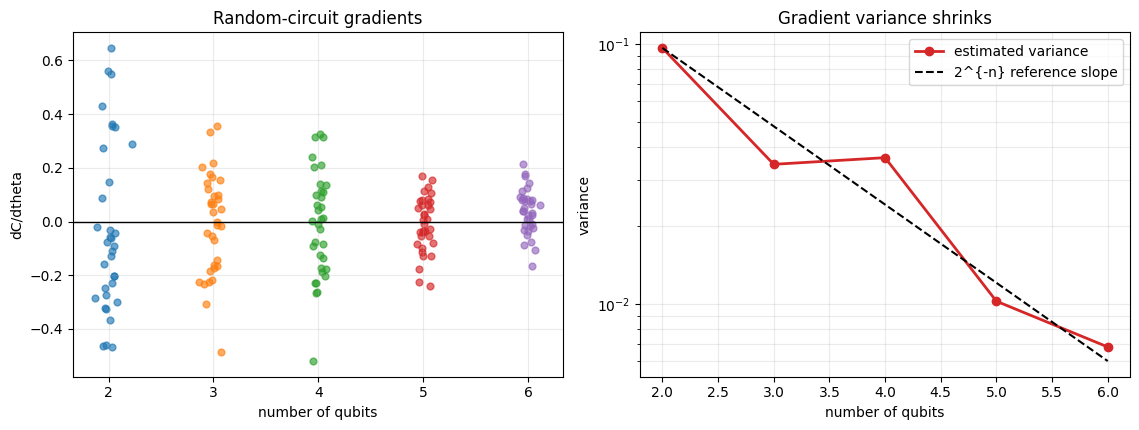

n=2: variance=9.636e-02
n=3: variance=3.439e-02
n=4: variance=3.648e-02
n=5: variance=1.023e-02
n=6: variance=6.824e-03


In [5]:
# Pseudo-code:
#   1. sample random circuits for multiple qubit counts
#   2. measure one parameter-shift gradient per trial
#   3. estimate gradient variance
#   4. plot the barren-plateau trend

# Barren plateau toy experiment: gradient variance versus number of qubits.
# Setup: imports and initial values for this cell.
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml

rng = np.random.default_rng(31)
qubit_counts = [2, 3, 4, 5, 6]
trials = 34
depth = 5
gradient_samples = []
variances = []

for n_qubits in qubit_counts:
    # Iterate through this part of the algorithm.
    dev = qml.device("default.qubit", wires=n_qubits)
    # Create the quantum simulator backend.
    observable = qml.prod(*[qml.PauliZ(wire) for wire in range(n_qubits)])

    @qml.qnode(dev)
    def random_cost(parameters):
        # Define the reusable computation for this cell.
        for layer in range(depth):
            # Iterate through this part of the algorithm.
            for wire in range(n_qubits):
                # Iterate through this part of the algorithm.
                qml.RY(parameters[layer, wire, 0], wires=wire)
                # Apply a quantum operation or declare a measurement.
                qml.RZ(parameters[layer, wire, 1], wires=wire)
                # Apply a quantum operation or declare a measurement.
            for wire in range(n_qubits - 1):
                # Iterate through this part of the algorithm.
                qml.CNOT(wires=[wire, wire + 1])
                # Apply a quantum operation or declare a measurement.
            qml.CNOT(wires=[n_qubits - 1, 0])
            # Apply a quantum operation or declare a measurement.
        return qml.expval(observable)
        # Return the computed output for the caller.

    gradients = []
    # Compute a gradient signal for parameter updates.
    for _ in range(trials):
        # Iterate through this part of the algorithm.
        parameters = rng.uniform(0.0, 2.0 * np.pi, size=(depth, n_qubits, 2))
        plus = parameters.copy()
        minus = parameters.copy()
        plus[0, 0, 0] += np.pi / 2.0
        minus[0, 0, 0] -= np.pi / 2.0
        gradient = 0.5 * (random_cost(plus) - random_cost(minus))
        # Compute a gradient signal for parameter updates.
        gradients.append(float(gradient))
        # Save this value so the learning trajectory can be plotted.

    gradients = np.array(gradients)
    # Compute a gradient signal for parameter updates.
    gradient_samples.append(gradients)
    # Save this value so the learning trajectory can be plotted.
    variances.append(np.var(gradients))
    # Save this value so the learning trajectory can be plotted.

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

for n_qubits, gradients in zip(qubit_counts, gradient_samples):
    # Iterate through this part of the algorithm.
    x_positions = np.full_like(gradients, n_qubits, dtype=float) + rng.normal(0.0, 0.045, size=len(gradients))
    axes[0].scatter(x_positions, gradients, s=24, alpha=0.65)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Random-circuit gradients")
axes[0].set_xlabel("number of qubits")
axes[0].set_ylabel("dC/dtheta")
axes[0].grid(alpha=0.25)

axes[1].semilogy(qubit_counts, variances, marker="o", color="tab:red", linewidth=2, label="estimated variance")
reference = variances[0] * 2.0 ** (-(np.array(qubit_counts) - qubit_counts[0]))
axes[1].semilogy(qubit_counts, reference, color="black", linestyle="--", label="2^{-n} reference slope")
axes[1].set_title("Gradient variance shrinks")
axes[1].set_xlabel("number of qubits")
axes[1].set_ylabel("variance")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

for n_qubits, variance in zip(qubit_counts, variances):
    # Iterate through this part of the algorithm.
    print(f"n={n_qubits}: variance={variance:.3e}")


## Practical takeaways

- Measurements turn quantum states into numerical model outputs.
- Parameter-shift gives exact gradients for many gate parameters using shifted circuit evaluations.
- VQCs can be trained with ordinary losses and manual gradient loops.
- PennyLane can connect quantum circuits to PyTorch, so quantum layers can sit inside larger neural networks.
- Barren plateaus are a real scaling risk. Shallow circuits, local costs, good initialization, problem-inspired ansatzes, and data re-uploading are common ways to reduce the risk.
